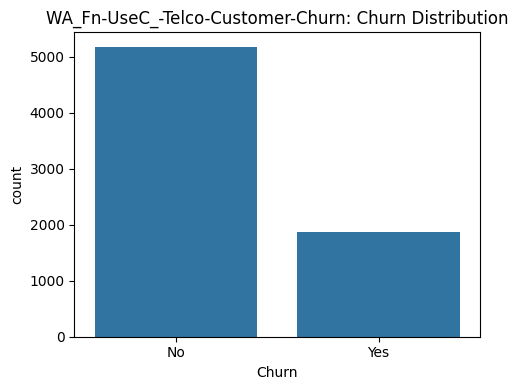

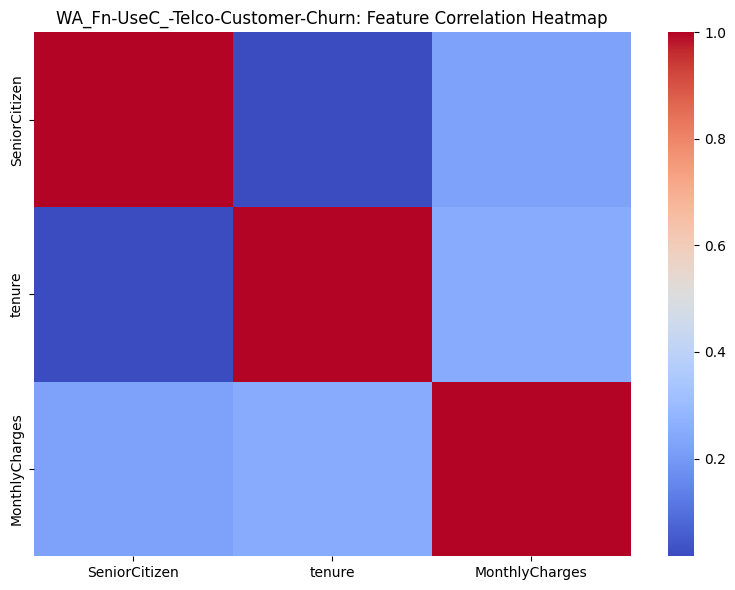

C:\Users\srkap\AppData\Local\Temp\ipykernel_18932\2564293157.py:56: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[target] = df[target].astype(str).str.lower().replace({'yes':1,'no':0,'true':1,'false':0})
c:\Users\srkap\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/60
150/150 - 9s - 60ms/step - accuracy: 0.7448 - loss: 0.5252 - val_accuracy: 0.7400 - val_loss: 0.5245
Epoch 2/60
150/150 - 5s - 36ms/step - accuracy: 0.8484 - loss: 0.3379 - val_accuracy: 0.7400 - val_loss: 0.4965
Epoch 3/60
150/150 - 5s - 35ms/step - accuracy: 0.9509 - loss: 0.1296 - val_accuracy: 0.7612 - val_loss: 0.5517
Epoch 4/60
150/150 - 5s - 35ms/step - accuracy: 0.9799 - loss: 0.0566 - val_accuracy: 0.7565 - val_loss: 0.6984
Epoch 5/60
150/150 - 5s - 32ms/step - accuracy: 0.9858 - loss: 0.0373 - val_accuracy: 0.7660 - val_loss: 1.0476
Epoch 6/60
150/150 - 5s - 31ms/step - accuracy: 0.9906 - loss: 0.0276 - val_accuracy: 0.7624 - val_loss: 0.9314
Epoch 7/60
150/150 - 5s - 30ms/step - accuracy: 0.9929 - loss: 0.0206 - val_accuracy: 0.7671 - val_loss: 1.0013
Epoch 8/60
150/150 - 5s - 32ms/step - accuracy: 0.9954 - loss: 0.0145 - val_accuracy: 0.7719 - val_loss: 1.0807


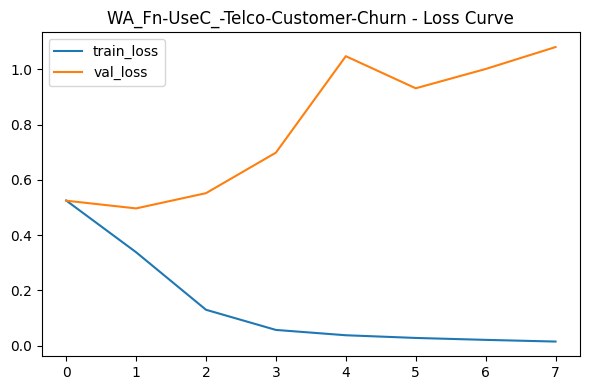

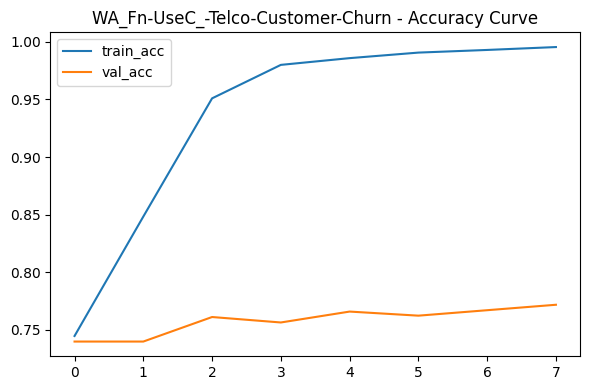

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


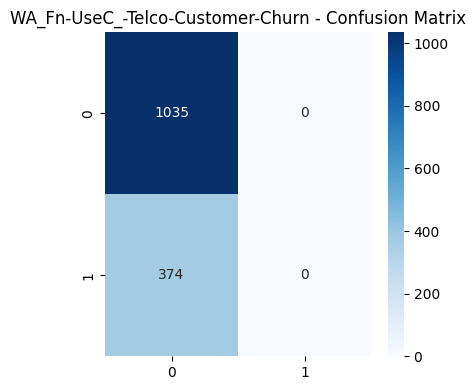

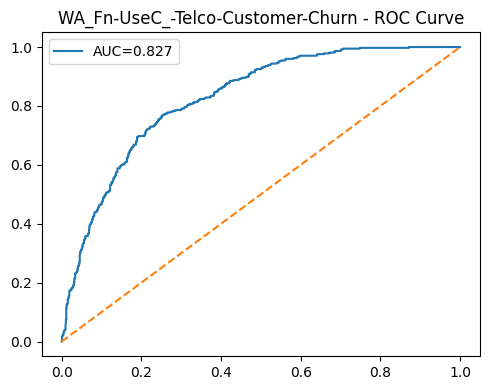

=== WA_Fn-UseC_-Telco-Customer-Churn RESULTS ===
Accuracy: 0.7345635202271115
ROC AUC: 0.8267767185925754
              precision    recall  f1-score   support

           0       0.73      1.00      0.85      1035
           1       0.00      0.00      0.00       374

    accuracy                           0.73      1409
   macro avg       0.37      0.50      0.42      1409
weighted avg       0.54      0.73      0.62      1409

⚠️ Missing C:/Users/srkap/OneDrive/Desktop/churn prediction/churn_prediction/dataset/bank_churn.csv, skipping.
⚠️ Missing C:/Users/srkap/OneDrive/Desktop/churn prediction/churn_prediction/dataset/ecommerce_churn.csv, skipping.

✅ Training Complete! Results saved in 'churn_resulthere/' folder.
                            Dataset  Accuracy   ROC_AUC
0  WA_Fn-UseC_-Telco-Customer-Churn  0.734564  0.826777


c:\Users\srkap\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\srkap\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\srkap\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [3]:
# churn_with_visuals.py
# ✅ Works perfectly in VS Code (.ipynb) — shows plots inline and saves them too.

%matplotlib inline

import os, random, numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from collections import Counter
from sklearn.preprocessing import OneHotEncoder
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, roc_auc_score, roc_curve, confusion_matrix, accuracy_score
)
from sklearn.impute import SimpleImputer
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

try:
    from imblearn.over_sampling import SMOTE
    IMBLEARN_AVAILABLE = True
except:
    IMBLEARN_AVAILABLE = False

# Fix randomness
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ==== CONFIG ====
dataset_paths = [
    "C:/Users/srkap/OneDrive/Desktop/churn prediction/churn_prediction/dataset/WA_Fn-UseC_-Telco-Customer-Churn.csv",
    "C:/Users/srkap/OneDrive/Desktop/churn prediction/churn_prediction/dataset/bank_churn.csv",
    "C:/Users/srkap/OneDrive/Desktop/churn prediction/churn_prediction/dataset/ecommerce_churn.csv"
]
RESULTS_DIR = "churn_results"
os.makedirs(RESULTS_DIR, exist_ok=True)
COMMON_TARGETS = ['Churn','churn','Exited','exited','target','label','is_churn']
# ================

def detect_target_col(df):
    for t in COMMON_TARGETS:
        if t in df.columns:
            return t
    return df.columns[-1]

def preprocess(df, target):
    df = df.copy()
    df.columns = [c.strip() for c in df.columns]
    if df[target].dtype == object:
        df[target] = df[target].astype(str).str.lower().replace({'yes':1,'no':0,'true':1,'false':0})
    df[target] = pd.to_numeric(df[target], errors='coerce').fillna(0).astype(int)
    y = df[target]
    X = df.drop(columns=[target])
    num_cols = X.select_dtypes(include=np.number).columns.tolist()
    cat_cols = X.select_dtypes(include=['object','category']).columns.tolist()
    return X, y, num_cols, cat_cols

def show_eda(df, target, dataset_name):
    # 1️⃣ Churn Distribution
    plt.figure(figsize=(5,4))
    sns.countplot(x=target, data=df)
    plt.title(f"{dataset_name}: Churn Distribution")
    plt.tight_layout()
    plt.savefig(f"{RESULTS_DIR}/{dataset_name}_class_dist.png")
    plt.show()  # 👈 Show inline

    # 2️⃣ Correlation heatmap for numeric columns
    numeric_df = df.select_dtypes(include=np.number)
    if numeric_df.shape[1] > 1:
        plt.figure(figsize=(8,6))
        sns.heatmap(numeric_df.corr(), cmap='coolwarm', annot=False)
        plt.title(f"{dataset_name}: Feature Correlation Heatmap")
        plt.tight_layout()
        plt.savefig(f"{RESULTS_DIR}/{dataset_name}_correlation.png")
        plt.show()  # 👈 Show inline

def build_preprocessor(num_cols, cat_cols):
    num_pipe = Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])
    
    # Version-safe OneHotEncoder
    if sklearn.__version__ >= '1.2':
        ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    else:
        ohe = OneHotEncoder(handle_unknown='ignore', sparse=False)
    
    cat_pipe = Pipeline([
        ('imp', SimpleImputer(strategy='most_frequent')),
        ('ohe', ohe)
    ])
    
    preprocessor = ColumnTransformer([
        ('num', num_pipe, num_cols),
        ('cat', cat_pipe, cat_cols)
    ])
    return preprocessor

def build_model(input_dim):
    model = Sequential([
        Dense(256, activation='relu', input_shape=(input_dim,)),
        BatchNormalization(),
        Dropout(0.3),
        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(0.2),
        Dense(64, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

def plot_training(history, name):
    # Loss Curve
    plt.figure(figsize=(6,4))
    plt.plot(history.history['loss'], label='train_loss')
    plt.plot(history.history['val_loss'], label='val_loss')
    plt.legend(); plt.title(f"{name} - Loss Curve")
    plt.tight_layout()
    plt.savefig(f"{RESULTS_DIR}/{name}_loss.png")
    plt.show()  # 👈 Show inline

    # Accuracy Curve
    plt.figure(figsize=(6,4))
    plt.plot(history.history['accuracy'], label='train_acc')
    plt.plot(history.history['val_accuracy'], label='val_acc')
    plt.legend(); plt.title(f"{name} - Accuracy Curve")
    plt.tight_layout()
    plt.savefig(f"{RESULTS_DIR}/{name}_accuracy.png")
    plt.show()  # 👈 Show inline

def plot_confusion(y_test, y_pred, name):
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{name} - Confusion Matrix")
    plt.tight_layout()
    plt.savefig(f"{RESULTS_DIR}/{name}_confusion.png")
    plt.show()  # 👈 Show inline

def plot_roc(y_test, y_proba, name):
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.figure(figsize=(5,4))
    plt.plot(fpr, tpr, label=f"AUC={auc:.3f}")
    plt.plot([0,1],[0,1],'--')
    plt.legend(); plt.title(f"{name} - ROC Curve")
    plt.tight_layout()
    plt.savefig(f"{RESULTS_DIR}/{name}_roc.png")
    plt.show()  # 👈 Show inline

def train_model(X, y, dataset_name):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED)
    pre = build_preprocessor(X_train.select_dtypes(include=np.number).columns.tolist(),
                             X_train.select_dtypes(exclude=np.number).columns.tolist())
    X_train_proc = pre.fit_transform(X_train)
    X_test_proc = pre.transform(X_test)

    if IMBLEARN_AVAILABLE:
        sm = SMOTE(random_state=SEED)
        X_train_proc, y_train = sm.fit_resample(X_train_proc, y_train)

    model = build_model(X_train_proc.shape[1])
    es = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)
    history = model.fit(X_train_proc, y_train, validation_split=0.15,
                        epochs=60, batch_size=32, callbacks=[es], verbose=2)
    
    # Show & save training graphs
    plot_training(history, dataset_name)

    # Predictions & visualizations
    y_proba = model.predict(X_test_proc).ravel()
    y_pred = (y_proba>=0.5).astype(int)
    plot_confusion(y_test, y_pred, dataset_name)
    plot_roc(y_test, y_proba, dataset_name)

    print(f"=== {dataset_name} RESULTS ===")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("ROC AUC:", roc_auc_score(y_test, y_proba))
    print(classification_report(y_test, y_pred))

    return {
        "Dataset": dataset_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "ROC_AUC": roc_auc_score(y_test, y_proba)
    }

def main():
    results = []
    for path in dataset_paths:
        if not os.path.exists(path):
            print(f"⚠️ Missing {path}, skipping.")
            continue
        df = pd.read_csv(path)
        target = detect_target_col(df)
        show_eda(df, target, os.path.splitext(os.path.basename(path))[0])
        X, y, _, _ = preprocess(df, target)
        result = train_model(X, y, os.path.splitext(os.path.basename(path))[0])
        results.append(result)

    # Save all metrics as CSV summary
    summary = pd.DataFrame(results)
    summary.to_csv(f"{RESULTS_DIR}/summary.csv", index=False)
    print("\n✅ Training Complete! Results saved in 'churn_resulthere/' folder.")
    print(summary)

if __name__ == "__main__":
    main()
